In [1]:
print('hello world')

hello world


In [2]:
from qiskit import *

In [3]:
from qiskit.compiler import transpile, assemble

In [4]:
#from qiskit.tools.jupyter import * (doesnt work anymore)
from qiskit.visualization import * #replacement 

In [5]:
qubit = QuantumRegister(1) #creating a qubit
cbit = ClassicalRegister(1) #creating a classical bit to store the output

In [6]:
print(cbit)

ClassicalRegister(1, 'c0')


In [7]:
#creating a quantum Crcuit
qc = QuantumCircuit(qubit, cbit)

In [8]:
print(qc.draw())

      
  q0: 
      
c0: 1/
      


q1 is the qubit line and c0 is the classic line 

In [9]:
#adding H gate to the circuit 
qc.h(0)

This is gate puts the qubit into a superposition state.

In [10]:
qc.draw()

┌───┐
  q0: ┤ H ├
      └───┘
c0: 1/═════

In [11]:
qc.measure(0,0) #here we are measuring a circuit

In [12]:
qc.draw()

┌───┐┌─┐
  q0: ┤ H ├┤M├
      └───┘└╥┘
c0: 1/══════╩═
            0

In [13]:
# from qiskit_aer import Aer
from qiskit_aer import Aer
from qiskit_aer import AerSimulator

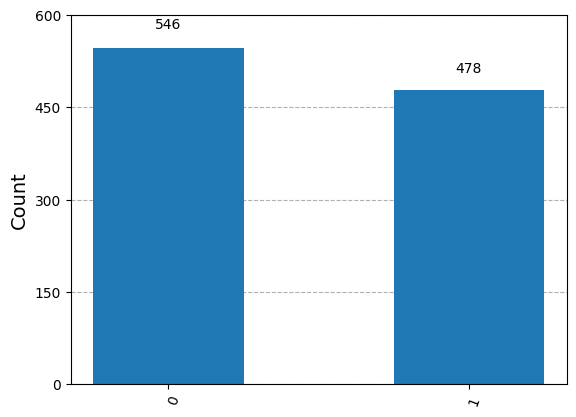

In [14]:
simulator = AerSimulator() # this simulates the behavior of  a quantum computer 
#Transpilation is the process of converting a quantum circuit into a form that can be executed on a specific quantum computer or simulator
compiled_circuit = transpile(qc, simulator) # this code takes the quantum circuit 'qc' and converts into a format that can be processed by the simulator.
sim_result = simulator.run(compiled_circuit).result() #runs a simulation of the quantum circuit and collects the results.
counts = sim_result.get_counts() # this extracts the measurement counts from the simulation results.
plot_histogram(counts)

In [15]:
from qiskit_aer import StatevectorSimulator 

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


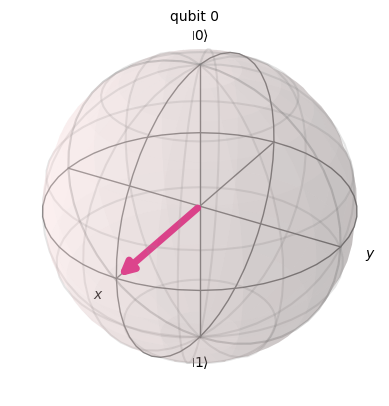

In [16]:
qc_1 = QuantumCircuit(1,1)
qc_1.h(0) #this applies the h gate or the Hadamerd gate
simulator_1 = StatevectorSimulator() 

# Execute the circuit and get the result
result_1 = simulator_1.run(qc_1).result() 

# Extract the statevector
psi = result_1.get_statevector(qc_1) #this takes results obtained and plots them in state vector format.

print(psi) 

# Plot the Bloch sphere representation
plot_bloch_multivector(psi) 


Statevector([ 0.70710678-8.65956056e-17j, -0.70710678+8.65956056e-17j],
            dims=(2,))


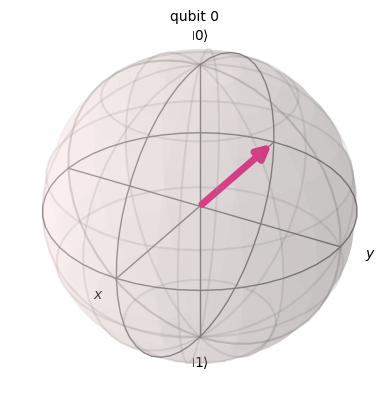

In [17]:

qc_2 = QuantumCircuit(1,1)
qc_2.x(0) # this applies the Xgate 
qc_2.h(0) #this applies the h gate or the Hadamerd gate



# Execute the circuit and get the result
result_2 = simulator_1.run(qc_2).result() 

# Extract the statevector
psi_1= result_2.get_statevector(qc_2) #this takes results obtained and plots them in state vector format.

print(psi_1) 

# Plot the Bloch sphere representation
plot_bloch_multivector(psi_1) 

Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))


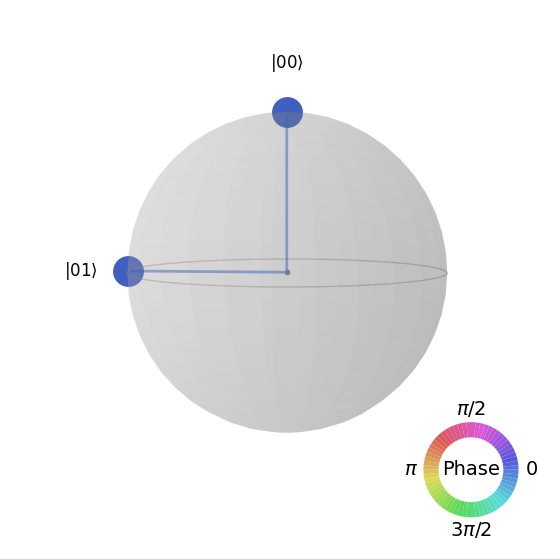

In [18]:
qc_3 = QuantumCircuit(2,2)

qc_3.h(0) #this applies the h gate or the Hadamerd gate

# qc_3.cx(0,1) # this applies the CXgate 

# we must apply the H gate first. As by defult every Quantum circuit when made the Qbit is in state |0> while the bit is in state |1>. The CX gate flips the target
# tartget quibit only if its in state |1>

# Execute the circuit and get the result
result_3 = simulator_1.run(qc_3).result() 

# Extract the statevector
psi_2= result_3.get_statevector(qc_3) #this takes results obtained and plots them in state vector format.

print(psi_2) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_2)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


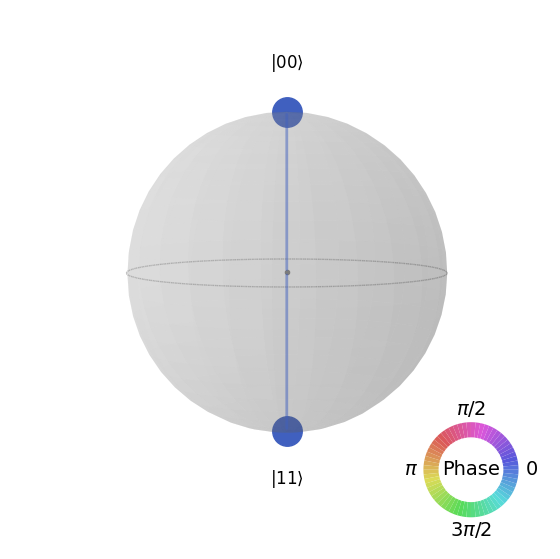

In [19]:
qc_3 = QuantumCircuit(2,2)

qc_3.h(0) #this applies the h gate or the Hadamerd gate

qc_3.cx(0,1) # this applies the CXgate 

# we must apply the H gate first. As by defult every Quantum circuit when made the Qbit is in state |0> while the bit is in state |1>. The CX gate flips the target
# tartget quibit only if its in state |1>

# Execute the circuit and get the result
result_3 = simulator_1.run(qc_3).result() 

# Extract the statevector
psi_2= result_3.get_statevector(qc_3) #this takes results obtained and plots them in state vector format.

print(psi_2) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_2)

now here when the cx gate is applied it will only flip the target qubit when control qubit is in state |1> and as there is only one qubit in state 1 only one target qubit is changed.

In [20]:
qc_3.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════

where X is the target qubit and the dot above is the control qubit.

Statevector([ 0.70710678-8.65956056e-17j,  0.        +0.00000000e+00j,
              0.        +0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2, 2))


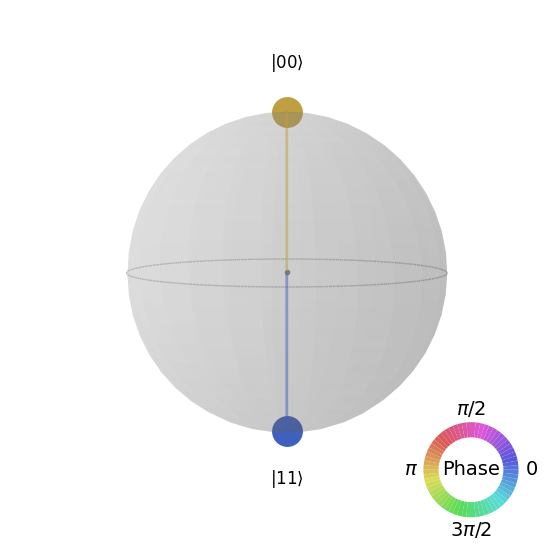

In [21]:
qc_4 = QuantumCircuit(2,2)
qc_4.x(0)
qc_4.h(0)
qc_4.cx(0,1)

result_4 = simulator_1.run(qc_4).result() 

# Extract the statevector
psi_4 = result_4.get_statevector(qc_4) #this takes results obtained and plots them in state vector format.

print(psi_4) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_4)

The diffrent colour tells you the phase diffrence here. They seem to be out of phase.

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


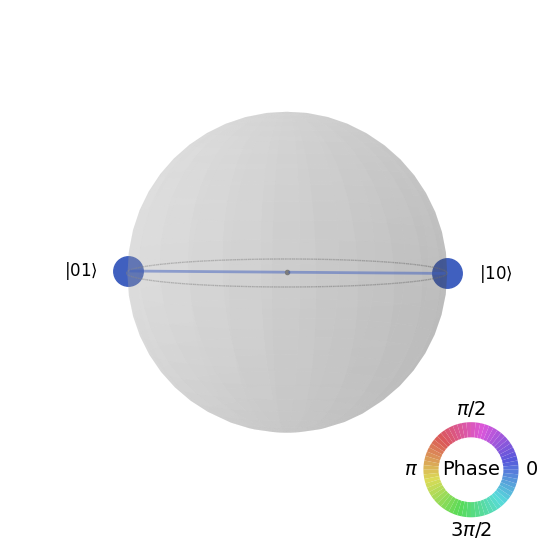

In [25]:
# Here I apply the X gate to the second qubit 

qc_5 = QuantumCircuit(2,2)
qc_5.x(1)
qc_5.h(0)
qc_5.cx(0,1)

result_5 = simulator_1.run(qc_5).result() 

# Extract the statevector
psi_5 = result_5.get_statevector(qc_5) #this takes results obtained and plots them in state vector format.

print(psi_5) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_5)

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


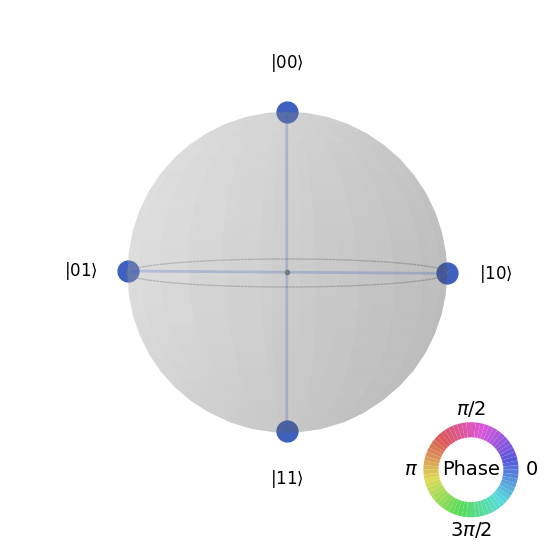

In [28]:
# Here I apply the X gate to the second qubit 

qc_6 = QuantumCircuit(2,2)
qc_6.h(1)
qc_6.h(0)
qc_6.cx(0,1)

result_6 = simulator_1.run(qc_6).result() 

# Extract the statevector
psi_6 = result_6.get_statevector(qc_6) #this takes results obtained and plots them in state vector format.

print(psi_6) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_6)

This created a superposition of all 4 states.

In [29]:
qc_6.draw()

┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ H ├┤ X ├
     └───┘└───┘
c: 2/══════════

### Bell States ###

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


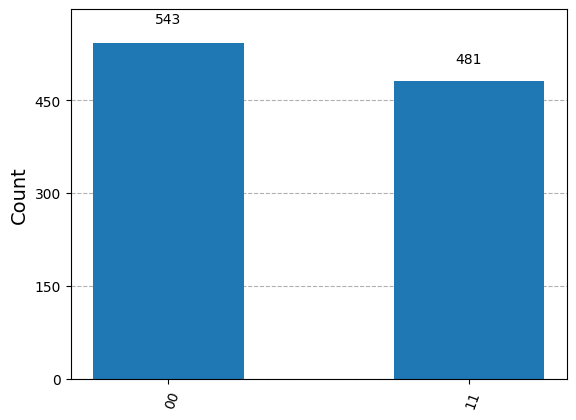

In [ ]:
# |Φ⁺⟩ state, Phi +
qc_7 = QuantumCircuit(2,2)
qc_7.h(0)
qc_7.cx(0,1)
qc_7.measure(0,0)
qc_7.measure(1,1)


result_7 = simulator_1.run(qc_7).result() 

# Extract the statevector
psi_7 = result_7.get_statevector(qc_7) #this takes results obtained and plots them in state vector format.

print(psi_7) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_7)

simulator = AerSimulator() 
compiled_circuit_7 = transpile(qc_7, simulator) 
sim_result_7 = simulator.run(compiled_circuit_7).result() 
counts_7 = sim_result_7.get_counts() 
plot_histogram(counts_7)

Here the probabilities should be listed as 0.523 |00> and 0.477 for |11> however for a unknown reason it's written in this format. Also it's possible that due to background noise the probabilties doesnt add up 1000

In [33]:
qc_7.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

Statevector([ 0.+0.0000000e+00j,  0.+0.0000000e+00j,  0.+0.0000000e+00j,
             -1.+1.2246468e-16j],
            dims=(2, 2))


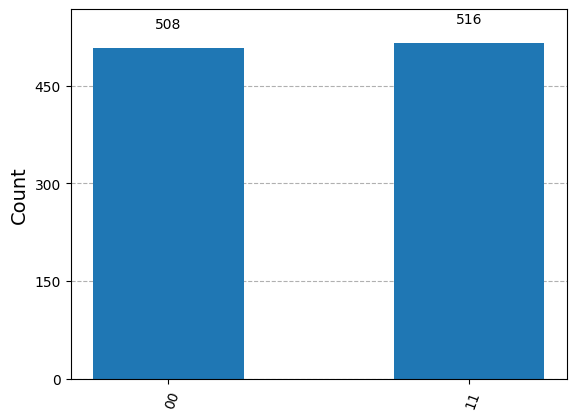

In [ ]:
# |Φ-⟩ state, Phi -
qc_9 = QuantumCircuit(2,2)
qc_9.x(0)
qc_9.h(0)
qc_9.cx(0,1)
qc_9.measure(0,0)
qc_9.measure(1,1)


result_9 = simulator_1.run(qc_9).result() 

# Extract the statevector
psi_9 = result_9.get_statevector(qc_9) #this takes results obtained and plots them in state vector format.

print(psi_9) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_9)

simulator = AerSimulator() 
compiled_circuit_9 = transpile(qc_9, simulator) 
sim_result_9 = simulator.run(compiled_circuit_9).result() 
counts_9 = sim_result_9.get_counts() 
plot_histogram(counts_9)

In [45]:
qc_9.draw()

┌───┐┌───┐     ┌─┐   
q_0: ┤ X ├┤ H ├──■──┤M├───
     └───┘└───┘┌─┴─┐└╥┘┌─┐
q_1: ──────────┤ X ├─╫─┤M├
               └───┘ ║ └╥┘
c: 2/════════════════╩══╩═
                     0  1

Statevector([ 0.+0.0000000e+00j, -0.+0.0000000e+00j,  1.-1.2246468e-16j,
              0.+0.0000000e+00j],
            dims=(2, 2))


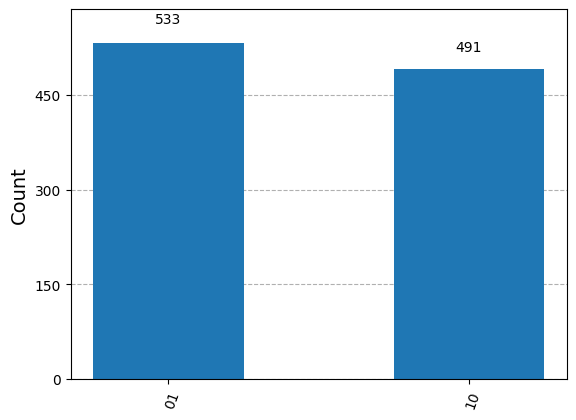

In [47]:
#PSI - Bell state  |Ψ⁻⟩
qc_8 = QuantumCircuit(2,2)
qc_8.x(0)
qc_8.x(1)
qc_8.h(0)
qc_8.cx(0,1)
qc_8.measure(0,0)
qc_8.measure(1,1)


result_8 = simulator_1.run(qc_8).result() 

# Extract the statevector
psi_8 = result_8.get_statevector(qc_8) #this takes results obtained and plots them in state vector format.

print(psi_8) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_8)

simulator = AerSimulator() 
compiled_circuit_8 = transpile(qc_8, simulator) 
sim_result_8 = simulator.run(compiled_circuit_8).result() 
counts_8 = sim_result_8.get_counts() 
plot_histogram(counts_8)

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


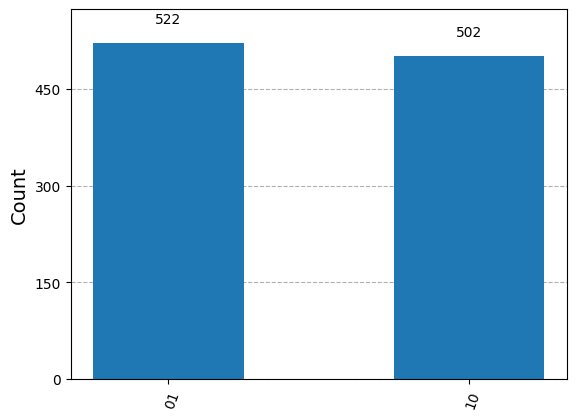

In [50]:
#|Ψ+⟩ Bell sate 
qc_10 = QuantumCircuit(2,2)
qc_10.h(0)
qc_10.x(1)
qc_10.cx(0,1)
qc_10.measure(0,0)
qc_10.measure(1,1)


result_10 = simulator_1.run(qc_10).result() 

# Extract the statevector
psi_10 = result_10.get_statevector(qc_10) #this takes results obtained and plots them in state vector format.

print(psi_10) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_10)

simulator = AerSimulator() 
compiled_circuit_10 = transpile(qc_10, simulator) 
sim_result_10 = simulator.run(compiled_circuit_10).result() 
counts_10 = sim_result_10.get_counts() 
plot_histogram(counts_10)

Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))


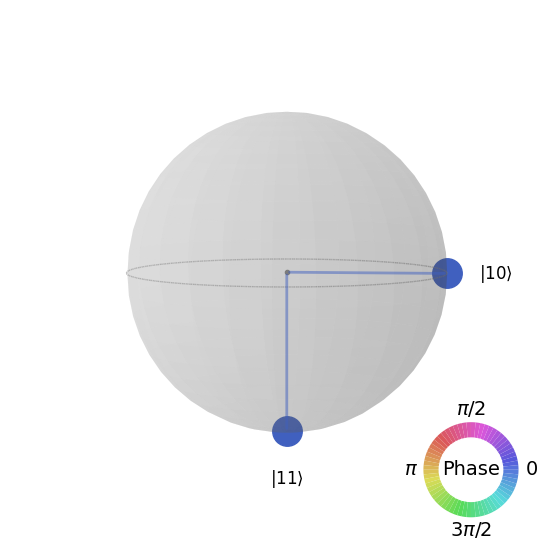

In [61]:
qc_t = QuantumCircuit(2,2)
qc_t.h(0)
qc_t.x(1)
# qc_t.measure(0,0)
# qc_t.measure(1,1)

result_t = simulator_1.run(qc_t).result() 

# Extract the statevector
psi_t = result_t.get_statevector(qc_t) #this takes results obtained and plots them in state vector format.

print(psi_t) 

# Plot the Bloch sphere representation
plot_state_qsphere(psi_t)